In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('/home/tec/Projects/machine_learning/dataset/credit_card_frauds.csv')

In [4]:
# 1. Converter as colunas de texto (string) para o formato datetime do Pandas
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# 2. Calcular a idade em anos no exato momento em que a fraude/transação ocorreu
df['idade'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# 3. Remover a coluna original 'dob', pois ela cumpriu seu propósito
df = df.drop(columns=['dob'])

# 4. Remove a coluna temporal que já usamos para calcular a idade
df = df.drop(columns=['trans_date_trans_time'], errors='ignore')

In [5]:
# 1. Definir a função matemática para calcular a distância esférica
def calcular_haversine(lat1, lon1, lat2, lon2):
    # Converte graus para radianos
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Diferença das coordenadas
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Fórmula de Haversine
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Raio da Terra em km
    r = 6371.0 
    return c * r

# 2. Aplicar a função criando a nova feature contínua
df['distancia_km'] = calcular_haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# 3. Eliminar as coordenadas absolutas (ruído espacial)
df = df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'])

In [6]:
# Exclui o identificador único da transação
df = df.drop(columns=['trans_num'])

In [7]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
# 1. Instanciar o RobustScaler
scaler = RobustScaler()

# 2. Ajustar (fit) e transformar (transform) a coluna 'amt'
# O Pandas exige colchetes duplos [['amt']] porque o Scikit-Learn espera um array 2D
df['amt'] = scaler.fit_transform(df[['amt']])

In [8]:
# Verifica se as colunas velhas sumiram, se 'idade' e 'distancia_km' apareceram
# e se todos os tipos de dados (Dtype) restantes são numéricos (int64 ou float64)
df.info()

# Verifica se a coluna 'amt' agora está padronizada (valores orbitando perto de 0, com extremos preservados)
display(df[['amt', 'idade', 'distancia_km']].describe())

<class 'pandas.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   merchant      339607 non-null  str    
 1   category      339607 non-null  str    
 2   amt           339607 non-null  float64
 3   city          339607 non-null  str    
 4   state         339607 non-null  str    
 5   city_pop      339607 non-null  int64  
 6   job           339607 non-null  str    
 7   is_fraud      339607 non-null  int64  
 8   idade         339607 non-null  int64  
 9   distancia_km  339607 non-null  float64
dtypes: float64(2), int64(3), str(5)
memory usage: 25.9 MB


,amt,idade,distancia_km
count,339607.000000,339607.000000,339607.000000
mean,0.327024,47.329808,75.577644
std,2.192207,17.033876,29.054393
min,-0.616407,17.000000,0.205072
25%,-0.499797,34.000000,54.734118
50%,0.000000,45.000000,77.612616
75%,0.500203,58.000000,97.947789
max,391.897492,93.000000,152.117173


In [9]:
# 1. Separação entre Features e Label
# Regressão Logística só utiliza valores numéricos
df_numerico = df.select_dtypes(include=[np.number])

features = df_numerico.drop(columns=['is_fraud'])
label = df_numerico['is_fraud']

# 2. Divisão em Treino e Teste (80% Treino, 20% Teste)
# O parâmetro 'stratify' é crucial em cibersegurança: ele garante que a mesma 
# proporção minúscula de fraudes exista tanto no treino quanto no teste.
features_train, features_test, label_train, label_test = train_test_split(features, label, test_size=0.2, random_state=42, stratify=label)

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Simula um sistema burro que aprova TODAS as transações (prevê sempre 0 - Legítima)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(features_train, label_train)
label_pred_dummy = dummy.predict(features_test)

print("--- RESULTADOS DO BASELINE (REGRA CEGA) ---")
print(f"Acurácia:  {accuracy_score(label_test, label_pred_dummy):.4f}")
print(f"Recall:    {recall_score(label_test, label_pred_dummy):.4f}")
print("-" * 40)

--- RESULTADOS DO BASELINE (REGRA CEGA) ---
Acurácia:  0.9948
Recall:    0.0000
----------------------------------------


SEM BALANCEAMENTO DE PESOS:

In [11]:
# from sklearn.linear_model import LogisticRegression

# # Instancia o modelo linear sem nenhum tratamento de peso ou balanceamento
# log_reg = LogisticRegression(max_iter=1000, random_state=42)
# log_reg.fit(features_train, label_train)
# label_pred_log = log_reg.predict(features_test)

# print("\n--- RESULTADOS DA REGRESSÃO LOGÍSTICA (SEM BALANCEAMENTO) ---")
# print(f"Acurácia:  {accuracy_score(label_test, label_pred_log):.4f}")
# print(f"Precisão:  {precision_score(label_test, label_pred_log, zero_division=0):.4f}")
# print(f"Recall:    {recall_score(label_test, label_pred_log):.4f}")
# print(f"F1-Score:  {f1_score(label_test, label_pred_log):.4f}")

# print("\n--- MATRIZ DE CONFUSÃO ---")
# cm = confusion_matrix(label_test, label_pred_log)
# print(f"Verdadeiros Negativos (TN): {cm[0][0]}")
# print(f"Falsos Positivos      (FP): {cm[0][1]}")
# print(f"Falsos Negativos      (FN): {cm[1][0]}")
# print(f"Verdadeiros Positivos (TP): {cm[1][1]}")

COM BALANCEAMENTO DE PESOS:

In [38]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Definimos uma lista com os pesos que queremos testar para a classe 1 (Fraude)
lista_pesos = [100]

# Criamos uma lista vazia para ir guardando os resultados de cada rodada
resultados_pesos = []

print("Iniciando bateria de testes com múltiplos pesos...\n")

# O loop vai rodar o modelo uma vez para cada peso da nossa lista
for peso_atual in lista_pesos:
    
    # Atualiza o dicionário com o peso da rodada atual
    pesos_manuais = {0: 1, 1: peso_atual}
    
    # Instancia o modelo linear
    log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight=pesos_manuais)
    log_reg.fit(features_train, label_train)
    
    # Faz as predições
    # label_pred_log = log_reg.predict(features_test)
    
    probabilidades_fraude = log_reg.predict_proba(features_test)[:, 1]

    limiar_customizado = 0.50

    label_pred_log = (probabilidades_fraude >= limiar_customizado).astype(int)

    # Matriz de confusão 
    cm = confusion_matrix(label_test, label_pred_log)
    
    # Salva as métricas desta rodada no dicionário 
    resultados_pesos.append({
        'Peso_Fraude': peso_atual,
        'Acurácia': accuracy_score(label_test, label_pred_log),
        'Precisão': precision_score(label_test, label_pred_log, zero_division=0),
        'Recall': recall_score(label_test, label_pred_log),
        'F1-Score': f1_score(label_test, label_pred_log),
        'TN': cm[0][0],
        'FP': cm[0][1], # Falsos Positivos (Bloqueios indevidos)
        'FN': cm[1][0], # Falsos Negativos (Fraudes que passaram)
        'TP': cm[1][1]  # Verdadeiros Positivos (Fraudes pegas)
    })

# Transforma a lista de resultados em um DataFrame do Pandas
df_resultados_pesos = pd.DataFrame(resultados_pesos)

# Exibe a tabela final completa
print("--- RESULTADOS DA REGRESSÃO LOGÍSTICA (MÚLTIPLOS PESOS) ---")
display(df_resultados_pesos)

Iniciando bateria de testes com múltiplos pesos...

--- RESULTADOS DA REGRESSÃO LOGÍSTICA (MÚLTIPLOS PESOS) ---


,Peso_Fraude,Acurácia,Precisão,Recall,F1-Score,TN,FP,FN,TP
0,100,0.976782,0.140247,0.668539,0.231856,66107,1459,118,238


In [ ]:
0	100	0.976782	0.140247	0.668539	0.231856	66107	1459	118	238


PLOTAGEM:

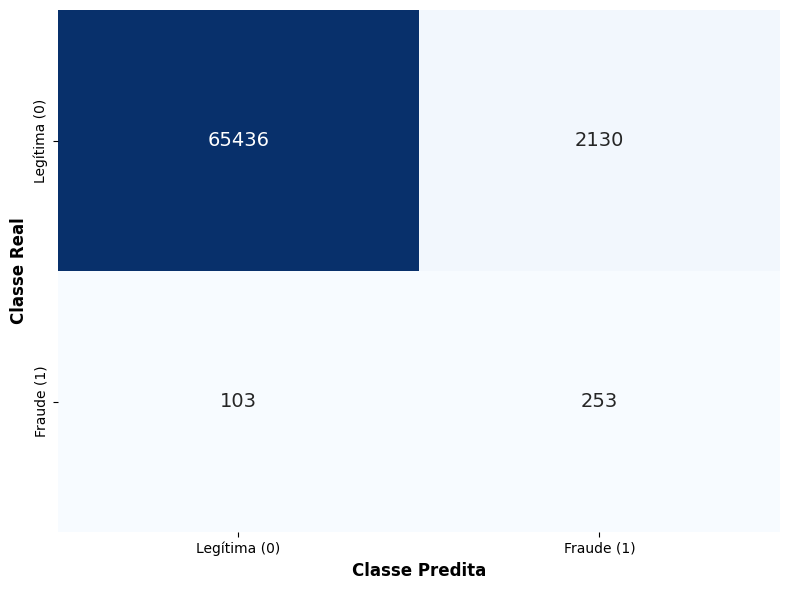

In [ ]:
#PLOT
import matplotlib.pyplot as plt

# Configurando o tamanho da figura
plt.figure(figsize=(8, 6))

# Criando o mapa de calor (heatmap)
# annot=True: coloca os números dentro dos quadrados
# fmt='d': garante que os números apareçam como inteiros e não em notação científica (ex: 6.7e+04)
# cmap='Blues': esquema de cores (você pode trocar para 'Reds' para dar um tom de "alerta")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legítima (0)', 'Fraude (1)'],
            yticklabels=['Legítima (0)', 'Fraude (1)'],
            annot_kws={"size": 14}) # Aumenta o tamanho da fonte dos números

# Adicionando rótulos e título para o seu relatório
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.xlabel('Classe Predita', fontsize=12, fontweight='bold')

plt.savefig('results/matriz_confusao_baseline.pdf', dpi=300, bbox_inches='tight')

# Ajusta o layout para não cortar os textos e exibe o gráfico
plt.tight_layout()
plt.show()

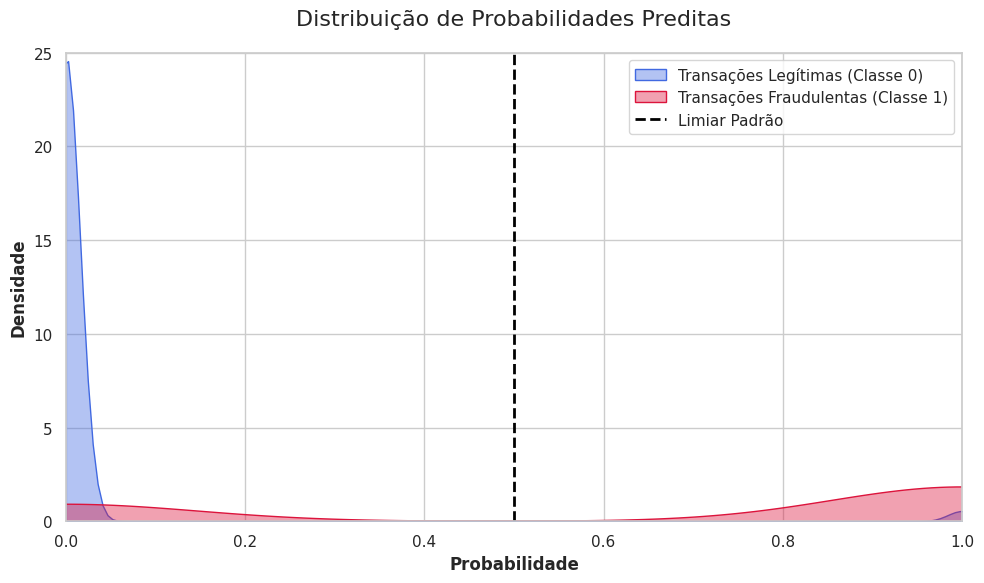

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
# 2. Separar as probabilidades em dois arrays distintos com base na realidade (label_test)
prob_legitimas = label_pred_log[label_test == 0]
prob_fraudes = label_pred_log[label_test == 1]

# 3. Configurar o tamanho e o estilo da figura
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") # Adiciona um grid sutil e elegante ao fundo

# 4. Plotar as curvas de densidade (KDE - Kernel Density Estimation)
# fill=True colore o interior, alpha controla a transparência para vermos a sobreposição
sns.kdeplot(prob_legitimas, color='royalblue', fill=True, alpha=0.4, label='Transações Legítimas (Classe 0)')
sns.kdeplot(prob_fraudes, color='crimson', fill=True, alpha=0.4, label='Transações Fraudulentas (Classe 1)')

# 5. Desenhar linhas verticais para ilustrar a calibração de limiares (Threshold Tuning)
plt.axvline(0.50, color='black', linestyle='--', linewidth=2, label='Limiar Padrão')
# plt.axvline(0.40, color='darkorange', linestyle='--', linewidth=2, label='Limiar Otimizado(40%)')

# 6. Formatação do título e dos eixos
plt.title('Distribuição de Probabilidades Preditas', fontsize=16, pad=20)
plt.xlabel('Probabilidade', fontsize=12, fontweight='bold')
plt.ylabel('Densidade', fontsize=12, fontweight='bold')

# Força o eixo X a ir estritamente de 0 (0%) a 1 (100%)
plt.xlim(0, 1)
plt.ylim(0, 25)

# Posiciona a legenda no topo para não cobrir as curvas
plt.legend(loc='upper right', frameon=True)

# 7. Ajustar o layout e salvar em alta resolução para o PDF
plt.tight_layout()
plt.savefig('results/distribuicao_probabilidades.pdf', dpi=300, bbox_inches='tight')
plt.show()

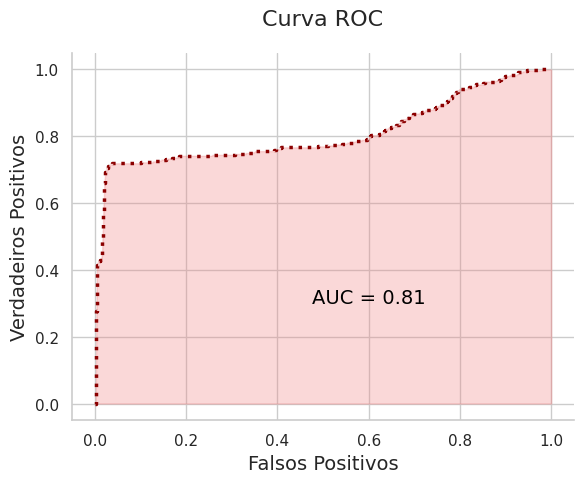

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Extração de probabilidades e cálculos
auc_score = roc_auc_score(label_test, probabilidades_fraude)
fpr, tpr, thresholds = roc_curve(label_test, probabilidades_fraude)

# Cria a figura e o eixo (ax) para termos mais controle sobre as bordas
fig, ax = plt.subplots(figsize=(6, 5))

# 2. Plota a Curva ROC (Linha pontilhada escura)
ax.plot(fpr, tpr, color='darkred', linestyle=':', linewidth=2.5)

plt.title('Curva ROC', fontsize=16, pad=20)

# 3. Sombreia a área sob a curva
# alpha=0.3 garante que a cor fique suave como na sua imagem de referência
ax.fill_between(fpr, tpr, color='lightcoral', alpha=0.3)

# 4. Adiciona o texto do AUC diretamente dentro da área sombreada
# As coordenadas (0.6, 0.3) centralizam o texto na mancha de cor
ax.text(0.6, 0.3, f'AUC = {auc_score:.2f}', fontsize=14, color='black', ha='center')

# 5. Formatação minimalista dos eixos
ax.set_xlabel('Falsos Positivos', fontsize=14)
ax.set_ylabel('Verdadeiros Positivos', fontsize=14)

# 6. Limpeza visual: Remove as bordas do topo e da direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Deixa as linhas dos eixos X e Y um pouco mais evidentes
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Salva a imagem com fundo transparente ou branco
plt.tight_layout()
plt.savefig('results/curva_roc.pdf', dpi=300, bbox_inches='tight', transparent=False)
plt.show()